In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

setLatex = False

import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

#import pybinding as pb
import matplotlib.pyplot as plt
import numpy as np
import copy
import os
import re

import sys
from IPython.display import Math

#from matplotlib import rc
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
#rc('font',**{'family':'serif','serif':['Palatino']})
#rc('text', usetex=True)



from copy import deepcopy

from scipy.spatial import cKDTree
from math import pi, sqrt
#from pybinding.repository.graphene import a, a_cc, t
import pickle
import scipy.ndimage.filters

import matplotlib

from pylab import *

import matplotlib.gridspec as gridspec


def latexify(fig_width=None, fig_height=None, columns=1):
    """Set up matplotlib's RC params for LaTeX plotting.
    Call this before plotting a figure.

    Parameters
    ----------
    fig_width : float, optional, inches
    fig_height : float,  optional, inches
    columns : {1, 2}
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    assert(columns in [1,2])

    if fig_width is None:
        fig_width = 3.39 if columns==1 else 6.9 # width in inches

    if fig_height is None:
        golden_mean = (sqrt(5)-1.0)/2.0    # Aesthetic ratio
        fig_height = fig_width*golden_mean # height in inches

    #MAX_HEIGHT_INCHES = 7.0
    #if fig_height > MAX_HEIGHT_INCHES:
    #    print("WARNING: fig_height too large:" + fig_height + 
    #          "so will reduce to" + MAX_HEIGHT_INCHES + "inches.")
    #    fig_height = MAX_HEIGHT_INCHES

    params = {'backend': 'ps',
              'text.latex.preamble': [r'\usepackage{gensymb}'],
              'axes.labelsize': 8, # fontsize for x and y labels (was 10)
              'axes.titlesize': 8,
              'font.size': 8, # was 10
              'legend.fontsize': 8, # was 10
              'xtick.labelsize': 8,
              'ytick.labelsize': 8,
              'text.usetex': True,
              'figure.figsize': [fig_width,fig_height],
              #'font.family': 'serif',
              'font.family' : 'Helvetica',
              'figure.autolayout': True,
              'lines.linewidth' : 1.0
    }

    matplotlib.rcParams.update(params)


def format_axes(ax):
    
    SPINE_COLOR = 'gray'

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(SPINE_COLOR)
        ax.spines[spine].set_linewidth(0.5)

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_tick_params(direction='out', color=SPINE_COLOR)

#q_sigma = c0 * 22.2  # [nm] hopping fitting parameter
#q_pi = a_cc * 22.2  # [nm] hopping fitting parameter
#r0 = 0.184 * a  # [nm] hopping fitting parameter




from mpl_toolkits.axes_grid1 import make_axes_locatable


def getBandstructure(dir1, nPlotBands, EShift):

    f = open(dir1+'/generate.bands.dat','r')
    print(f)
    
    
    i = 0
    j = 0
    l = 0
    
    k = []
    E = []
    
    kVec = []
    EVec = []
    
    counterPlotBands = 0
    
    for line in f:
        i = i+1
        a = line.split()
        if i==10:
            nbands = int(a[5])
            print(nbands)
            nk = int(a[7])
            print(nbands,nk)
        if i>16:
            if len(a)==0:
                j = j+0.5
                #print(j)
            else:
                if (int(j)==int(nbands/2-nPlotBands/2 + counterPlotBands) and int(j) < int(nbands/2+nPlotBands/2)):
                    if l<nk:
                        k.append(float(a[0]))
                        E.append(float(a[1])-EShift)
                        l = l+1
                    if l==nk:
                        kVec.append(k)
                        EVec.append(E)
                        l = 0
                        counterPlotBands += 1
                        k = []
                        E = []
                        
    return kVec, EVec

def getSingleBand3(dir1, EShift, bandIndex):

    f = open(dir1+'/generate.bands.dat','r')
    
    
    i = 0
    j = 0
    l = 0
    
    k = []
    E = []
    
    kVec = []
    EVec = []
    
    counterPlotBands = 0
    
    for line in f:
        i = i+1
        a = line.split()
        if i==10:
            nbands = int(a[5])
            nk = int(a[7])
            #print(nbands,nk)
        if i>14:
            if len(a)==0:
                j = j+0.5
                #print(j)
            else:
                #print(nbands)
                if (int(j)==int(nbands/2) + bandIndex):
                    if l<nk:
                        k.append(float(a[0]))
                        E.append(float(a[1])-EShift)
                        l = l+1
                    if l==nk:
                        kVec.append(k)
                        EVec.append(E)
                        l = 0
                        counterPlotBands += 1
                        k = []
                        E = []
                        
    return kVec, EVec
                
def getGap(dir1, EShift):
    Emin = 10000000
    Emax = -10000000
    bandIndexVec = [-1]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.max(EVec)>Emax):
            Emax = np.max(EVec)
        #if (np.min(EVec)<Emin):
        #    Emin= np.min(EVec)
    bandIndexVec = [0]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.min(EVec)<Emin):
            Emin= np.min(EVec)
    gap = (Emin - Emax)*1000
    return gap

def getGap2(dir1, EShift):
    Emin = 10000000
    Emax = -10000000
    bandIndexVec = [-3]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.max(EVec)>Emax):
            Emax = np.max(EVec)
        #if (np.min(EVec)<Emin):
        #    Emin= np.min(EVec)
    bandIndexVec = [-2]
    for bandIndex in bandIndexVec:
        kVec, EVec = getSingleBand3(dir1, EShift, bandIndex)
        i = 0
        if (np.min(EVec)<Emin):
            Emin= np.min(EVec)
    gap = (Emin - Emax)*1000
    return gap

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def supercell_trans_matrices_m(a,b):#Herman equation 25
    m = np.array([[a,b], [-b, a+b]]) # Matrix m
    return m
def supercell_trans_matrices_mp(ap,bp):
    mp = np.array([[ap,bp], [-bp, ap+bp]]) # Matrix m_prime
    return mp

def number_of_moiron(a,b,ap,bp):#Hermann equation 24
    m = supercell_trans_matrices_m(a,b)
    mp = supercell_trans_matrices_mp(ap,bp)
    N = np.linalg.det(m-mp)
    return N

def number_of_atoms_in_1Moiron(a,b,ap,bp): #Hermann equation 30
    A = (ap - a)**2 + (bp - b)**2 + (ap - a)*(bp - b)  #Herman, Equation 31
    x = np.array([[(ap+bp)*(b-bp)+ap*(a-ap), (a*bp - b*ap)], [(b*ap - a*bp), (ap+bp)*(a-ap)+bp*(b-bp)]])
    final_matrix= x/A
    n = np.linalg.det(final_matrix)
    return n * 4 #2 atoms per unit cell in graphene

def total_atoms_per_Supercell(a,b,ap,bp):
    n = number_of_atoms_in_1Moiron(a,b,ap,bp)
    N = number_of_moiron(a,b,ap,bp)
    return round(N*n)

def alpha(a,b,ap,bp,p):#Herman equation 29
#     p = 0.98
    gamma = a**2 + b ** 2 + a*b #equation 27
    alpha_rad = np.arccos((2*ap*a + 2*bp*b+ap*b+bp*a)/(2*p*gamma))
    alpha_deg = alpha_rad*180/np.pi
    return alpha_deg

def p_param(a,b,ap,bp):
    return np.sqrt((ap**2+bp**2+ap*bp)/(a**2+b**2+a*b))

def P_range(): # Considering the tolerance of substrate lattice parameters, we will now have a range of 'P' values.
    R0p = 2.505759  # Lattice constant of BN
    R0 = 2.4602   # Lattice constant of graphene
    tol = 0.001
    return R0/(R0p+tol), R0/(R0p - tol)

plw,phi = P_range()

angles = []
num_atom = []
p_change = []

angles1 = []
num_atom1 = []

angles2 = []
num_atom2 = []

angles3 = []
num_atom3 = []

angles4 = []
num_atom4 = []

angles5 = []
num_atom5 = []

for a in range(-50,50):
        for b in range(-50,50):
            for ap in range(-50, 50):
                for bp in range(-50,50):
                    if (a != ap and b != bp and a != 0 and b != 0):
                        p = p_param(a,b,ap,bp)
                        if plw <= p <= phi:
                            num_atom.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles.append(angle)
                            p_change.append(p-(plw+phi)/2)
                        if plw/5 <= p <= phi/5:
                            num_atom1.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles1.append(angle)
                        elif plw*2/5 <= p <= phi*2/5:
                            num_atom2.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles2.append(angle)
                        elif plw*3/5 <= p <= phi*3/5:
                            num_atom3.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles3.append(angle)
                        elif plw*4/5 <= p <= phi*4/5:
                            num_atom4.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles4.append(angle)
                        elif plw <= p <= phi:
                            num_atom5.append(total_atoms_per_Supercell(a,b,ap,bp))
                            angle = alpha(a,b,ap,bp,p)
                            angles5.append(angle)

anglesA = [x - 120 if x > 120 else x for x in angles]

anglesB = [x - 60 if x > 60 else x for x in anglesA]

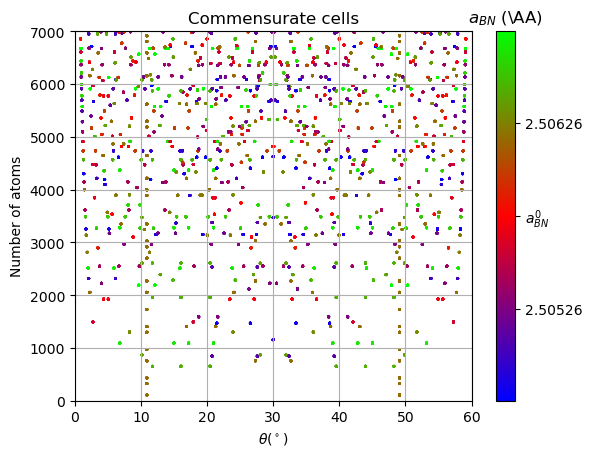

In [7]:
#latexify(columns=1)#, fig_height=3.5)  

g1 = gridspec.GridSpec(1, 1)#, height_ratios=[6,1])
g1.update(wspace=0.2, hspace=0.25) # set the spacing between axes.

fig, axes = plt.subplots(1, 1,sharey = "row")

ax0 = subplot(g1[0])


delta = []
for v in p_change:
    d = v*2.505759**2/(2.4602-v*2.505759)
    delta.append(d+2.505759)

im = ax0.scatter(anglesB,num_atom, c=delta, s=1,cmap="brg")
#ax0.title("Graphene on Hexagonal Boron Nitride", fontdict = {'family': 'serif',
#        'color':  'darkred','size': 20})
ax0.set_ylim(0, 7000)
ax0.set_xlim(0, 60)
cbar = fig.colorbar(im, ticks=[2.50576-0.0005, 2.50576, 2.50576+0.0005])
cbar.ax.set_yticklabels([2.50526, r'$a_{BN}^0$', 2.50576+0.0005 ])
cbar.ax.set_title(r'$a_{BN}$ (\AA)')
ax0.set_title("Commensurate cells")
#plt.grid()
#plt.xlabel("Angles in degree", color = 'red', fontsize = "large")
#plt.ylabel("Number of atoms", color = 'red', fontsize = 'large')
ax0.set_xlabel(r"$\theta (^\circ)$")#, fontsize = 20)
ax0.set_ylabel("Number of atoms")#,  fontsize = 20)
ax0.grid()

os.chdir("./")
fig.savefig("HermannGBN.png",dpi=1200,bbox_inches='tight')